In [ ]:
import numpy as np
import torch
import open3d as o3d
import igl
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern

from funcshape.surface import Surface

In [11]:
class PointCloudSurface(Surface):
    def __init__(self, points, uv=None, method="cubic", mesh_method="poisson"):
        """
        points: (N, 3) array of raw point cloud
        uv: optional (N, 2) parameterization
        method: interpolation method ('linear', 'nearest', 'cubic')
        mesh_method: 'poisson' or 'ballpivot'
        """
        self.points = np.asarray(points)
        self.method = method

        # Step 1: build mesh using Open3D
        mesh = self._build_mesh(self.points, method=mesh_method)
        V = np.asarray(mesh.vertices)
        F = np.asarray(mesh.triangles, dtype=np.int32)

        if uv is None:
            uv = self._harmonic_map(V, F)

        # Normalize to [0,1]^2
        uv = (uv - uv.min(0)) / (uv.max(0) - uv.min(0))
        self.uv = uv
        self.vertices, self.faces = V, F

        # Step 2: Fit Gaussian processes for mapping UV -> XYZ
        kernel = 1.0 * Matern(length_scale=1.0, nu=1.5)
        self.interps = []
        for i in range(3):
            gpr = GaussianProcessRegressor(kernel=kernel, random_state=23)
            gpr.fit(self.uv, self.vertices[:, i])
            self.interps.append(lambda x, gpr=gpr: gpr.predict(x))

        # Pass callable mapping into Surface base class
        super().__init__(
            (
                lambda x, i=i: torch.tensor(
                    self.interps[i](x.detach().cpu().numpy()),
                    dtype=torch.float32
                )
                for i in range(3)
            )
        )

    def _build_mesh(self, pts, method="poisson"):
        """Reconstruct a triangle mesh from point cloud using Open3D."""
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)

        # Estimate normals for meshing
        pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(
            radius=0.1, max_nn=30))

        if method == "poisson":
            mesh, _ = o3d.geometry.TriangleMesh.create_from_point_cloud_poisson(
                pcd, depth=8)
            mesh = mesh.filter_smooth_simple(number_of_iterations=5)
            mesh.remove_degenerate_triangles()
            mesh.remove_duplicated_triangles()
            mesh.remove_duplicated_vertices()
            mesh.remove_non_manifold_edges()
            mesh.compute_vertex_normals()

        elif method == "ballpivot":
            distances = pcd.compute_nearest_neighbor_distance()
            avg_dist = np.mean(distances)
            radius = 2.5 * avg_dist
            mesh = o3d.geometry.TriangleMesh.create_from_point_cloud_ball_pivoting(
                pcd, o3d.utility.DoubleVector([radius, radius * 2]))
            mesh.remove_degenerate_triangles()
            mesh.remove_duplicated_triangles()
            mesh.remove_duplicated_vertices()
            mesh.remove_non_manifold_edges()
            mesh.compute_vertex_normals()
        else:
            raise ValueError("Unknown mesh method: choose 'poisson' or 'ballpivot'")

        return mesh

    def _harmonic_map(self, V, F):
        """Compute harmonic parameterization with libigl."""
        # Step 1: boundary loop
        bnd = igl.boundary_loop(F)

        # Step 2: map boundary to circle
        bnd_uv = igl.map_vertices_to_circle(V, bnd)

        # Step 3: harmonic map
        uv = igl.harmonic(V, F, bnd, bnd_uv, 1)
        return uv


In [12]:
# Example: random noisy point cloud on a sphere
N = 100
theta = np.linspace(0, 2*np.pi, int(np.sqrt(N)))
phi = np.linspace(0, np.pi, int(np.sqrt(N)))
theta, phi = np.meshgrid(theta, phi)
x = np.cos(theta) * np.sin(phi)
y = np.sin(theta) * np.sin(phi)
z = np.cos(phi)
points = np.c_[x.ravel(), y.ravel(), z.ravel()]

surf = PointCloudSurface(points, mesh_method="poisson")

print("UV shape:", surf.uv.shape)  # (N, 2)
print("Vertices:", surf.vertices.shape, "Faces:", surf.faces.shape)


/Users/knv2/Documents/codebase/envs/funcshape/lib/python3.11/site-packages/sklearn/gaussian_process/_gpr.py:663: ConvergenceWarning: lbfgs failed to converge after 1 iteration(s) (status=2):
ABNORMAL: 

You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  _check_optimize_result("lbfgs", opt_res)


UV shape: (3716, 2)
Vertices: (3716, 3) Faces: (7045, 3)


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_pointcloud_surface(surface, n_grid=50):
    """
    Visualize:
    1) Original 3D point cloud
    2) UV embedding
    3) Interpolated surface on UV grid
    """
    pts = surface.points
    uv = surface.uv

    # ========== (1) Original 3D surface ==========
    fig = plt.figure(figsize=(15, 5))
    ax1 = fig.add_subplot(131, projection='3d')
    ax1.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=5)
    ax1.set_title("Original 3D Surface")

    # ========== (2) UV embedding ==========
    ax2 = fig.add_subplot(132)
    ax2.scatter(uv[:, 0], uv[:, 1], s=5)
    ax2.set_title("Harmonic UV Embedding")
    ax2.set_xlabel("u")
    ax2.set_ylabel("v")

    # ========== (3) Interpolated surface ==========
    # Create UV grid
    u = np.linspace(0, 1, n_grid)
    v = np.linspace(0, 1, n_grid)
    U, V = np.meshgrid(u, v)
    uv_grid = np.c_[U.ravel(), V.ravel()]

    # Evaluate surface interpolation
    X = surface.interps[0](uv_grid)
    Y = surface.interps[1](uv_grid)
    Z = surface.interps[2](uv_grid)

    ax3 = fig.add_subplot(133, projection='3d')
    ax3.plot_trisurf(X, Y, Z, cmap="viridis", linewidth=0.1, alpha=0.9)
    ax3.set_title("Reconstructed Surface from UV-grid")

    plt.tight_layout()
    plt.show()

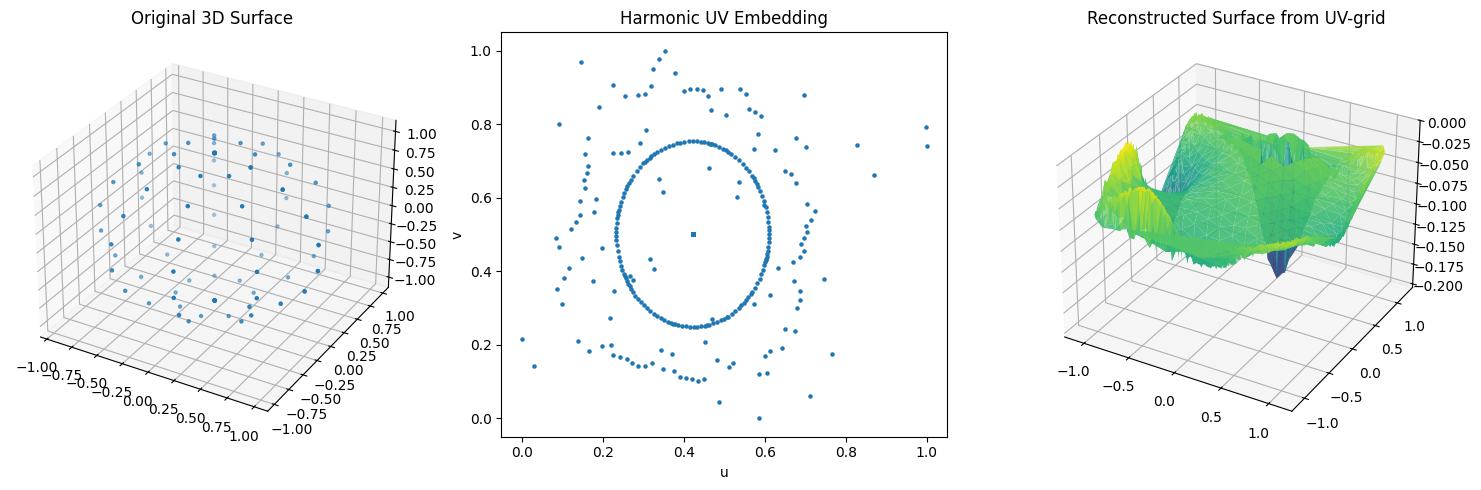

In [14]:
visualize_pointcloud_surface(surf, n_grid=60)

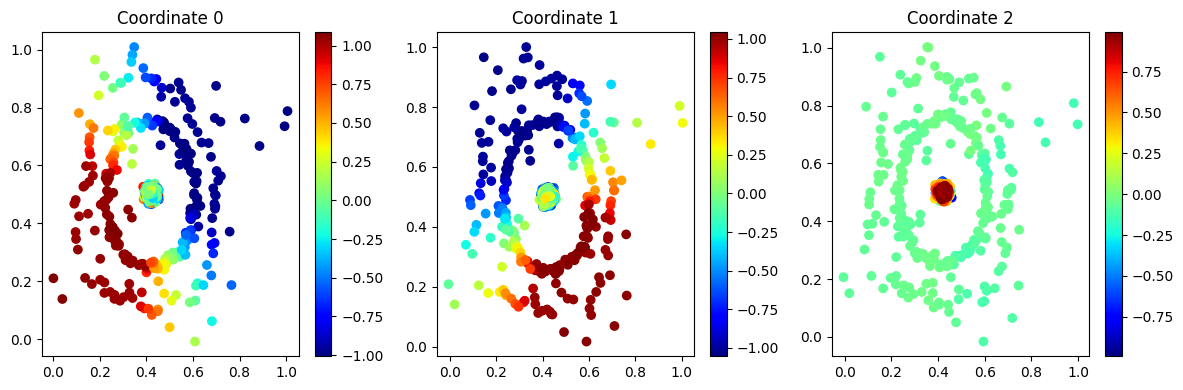

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
jitter = 1e-2
for i, ax in enumerate(axs):
    emb = surf.uv + np.random.normal(scale=jitter, size=surf.uv.shape)
    sc = ax.scatter(
        emb[:, 0], emb[:, 1],
        c=surf.vertices[:, i],
        cmap="jet"
    )
    fig.colorbar(sc, ax=ax)   # attach a colorbar to this subplot
    ax.set_title(f"Coordinate {i}")

plt.tight_layout()
plt.show()


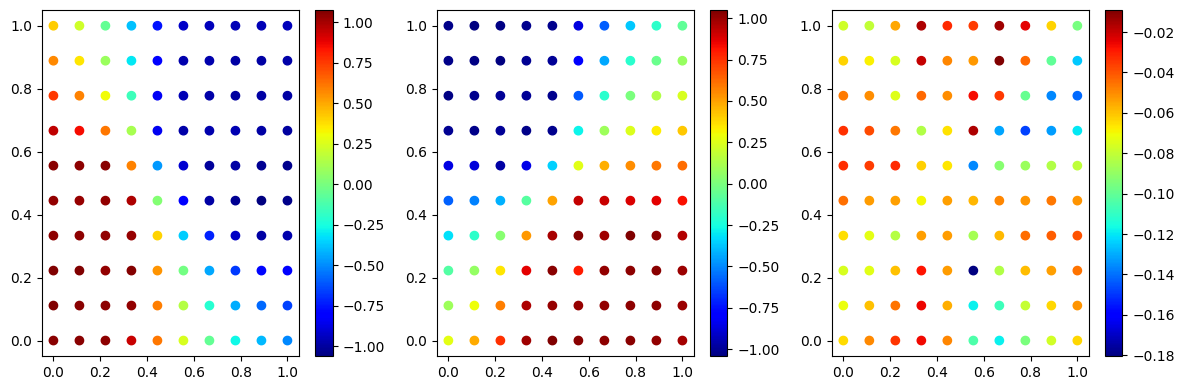

In [20]:
n_grid = 10
u = np.linspace(0, 1, n_grid)
v = np.linspace(0, 1, n_grid)
U, V = np.meshgrid(u, v)
uv_grid = np.c_[U.ravel(), V.ravel()]

# Evaluate surface interpolation
X = surf.interps[0](uv_grid)
Y = surf.interps[1](uv_grid)
Z = surf.interps[2](uv_grid)

fig, axs = plt.subplots(1,3, figsize=(4*3, 4))
for pts, ax in zip([X,Y,Z], axs):
    sc = ax.scatter(uv_grid[:,0], uv_grid[:,1], c = pts, cmap="jet")
    fig.colorbar(sc, ax=ax)   # attach a colorbar to this subplot

plt.tight_layout()
plt.show()